### 📉 Reducción de Granularidad y Optimización de Memoria

Al trabajar con Big Data, el mayor error es intentar procesar más información de la necesaria de forma local. Para evitar saturar la memoria RAM con 58 millones de filas cargadas de *lags* y características, ajustaremos nuestra estrategia:
* **El Objetivo:** Analizar la estacionalidad global y realizar una segmentación de tiendas (*Clustering*).
* **El Cambio de Nivel:** Para este propósito, no necesitamos el nivel de detalle de cada producto individual (*SKU*).
* **La Solución:** Aplicaremos agregaciones para reducir la granularidad del dataset, calculando únicamente las ventas totales diarias por tienda.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual de las gráficas para que parezcan de nivel directivo
sns.set_theme(style="whitegrid", context="talk")

# 1. Definimos la ruta de tu captura
ruta_parquet = "./data/processed/abt_master_full.parquet" 

print("Leyendo el dataset masivo y agregando a nivel de tienda...")

# Leemos solo las columnas necesarias para ahorrar muchísima memoria RAM
columnas_necesarias = ["store_id", "date", "wday", "event_name_1", "sales_qty"]
df_raw = pd.read_parquet(ruta_parquet, columns=columnas_necesarias)

# 2. Agrupamos los datos: Queremos la suma de ventas por tienda y día
# Mantenemos el día de la semana (wday) y los eventos. Usamos dropna=False para no perder los días sin festivos
df_tiendas = df_raw.groupby(
    ["store_id", "date", "wday", "event_name_1"], 
    dropna=False
)["sales_qty"].sum().reset_index()

# Limpiamos los nulos de la columna de eventos rellenándolos con "Sin Evento"
df_tiendas["event_name_1"] = df_tiendas["event_name_1"].fillna("Sin Evento")

print(f"✅ ¡Dataset preparado! Filas reducidas a: {df_tiendas.shape[0]}")

# 3. Perfilado estadístico del Director de Ventas
print("\n--- Resumen Estadístico de Ventas Diarias por Tienda ---")
display(df_tiendas.groupby("store_id")["sales_qty"].describe().round(0))

Leyendo el dataset masivo y agregando a nivel de tienda...
✅ ¡Dataset preparado! Filas reducidas a: 18850

--- Resumen Estadístico de Ventas Diarias por Tienda ---


,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
CA_1,1885.0,4036.0,990.0,0.0,3363.0,3912.0,4658.0,6948.0
CA_2,1885.0,2980.0,901.0,2.0,2328.0,2778.0,3456.0,6542.0
CA_3,1885.0,5872.0,1191.0,0.0,5133.0,5828.0,6580.0,9338.0
CA_4,1885.0,2155.0,422.0,0.0,1901.0,2181.0,2434.0,3343.0
TX_1,1885.0,2935.0,611.0,0.0,2543.0,2844.0,3325.0,5190.0
TX_2,1885.0,3782.0,790.0,0.0,3256.0,3646.0,4301.0,6793.0
TX_3,1885.0,3196.0,676.0,1.0,2741.0,3177.0,3642.0,6750.0
WI_1,1885.0,2706.0,994.0,0.0,1871.0,2661.0,3324.0,6902.0
WI_2,1885.0,3444.0,1280.0,0.0,2437.0,3522.0,4381.0,7852.0


Enriqueciendo el dataset con variables de calendario para el EDA...


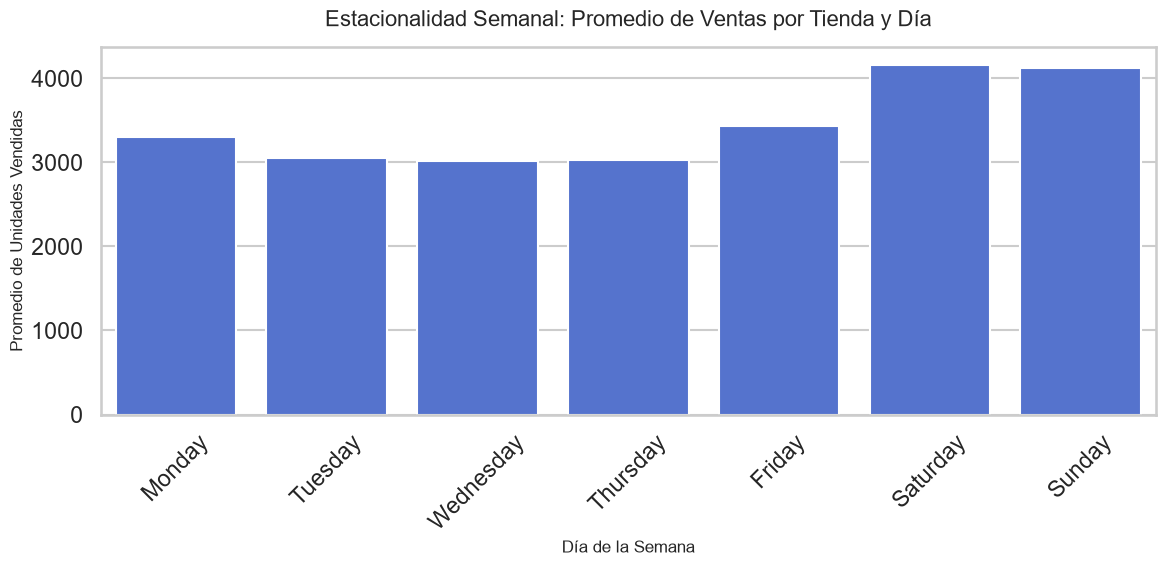

In [17]:
import calendar

print("Enriqueciendo el dataset con variables de calendario para el EDA...")

# 1. Convertimos la columna a formato fecha (datetime)
df_tiendas['date'] = pd.to_datetime(df_tiendas['date'])

# 2. Extraemos el mes y el nombre del día
df_tiendas['month'] = df_tiendas['date'].dt.month
df_tiendas['day_name'] = df_tiendas['date'].dt.day_name()

# 3. Forzamos un orden lógico para la semana (de Lunes a Domingo)
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# --- GRÁFICO 1: ESTACIONALIDAD SEMANAL ---
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_tiendas, 
    x='day_name', 
    y='sales_qty', 
    order=dias_orden, 
    color='royalblue',
    errorbar=None # Ocultamos las líneas de varianza para un gráfico más "ejecutivo"
)

plt.title('Estacionalidad Semanal: Promedio de Ventas por Tienda y Día', fontsize=16, pad=15)
plt.xlabel('Día de la Semana', fontsize=12)
plt.ylabel('Promedio de Unidades Vendidas', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

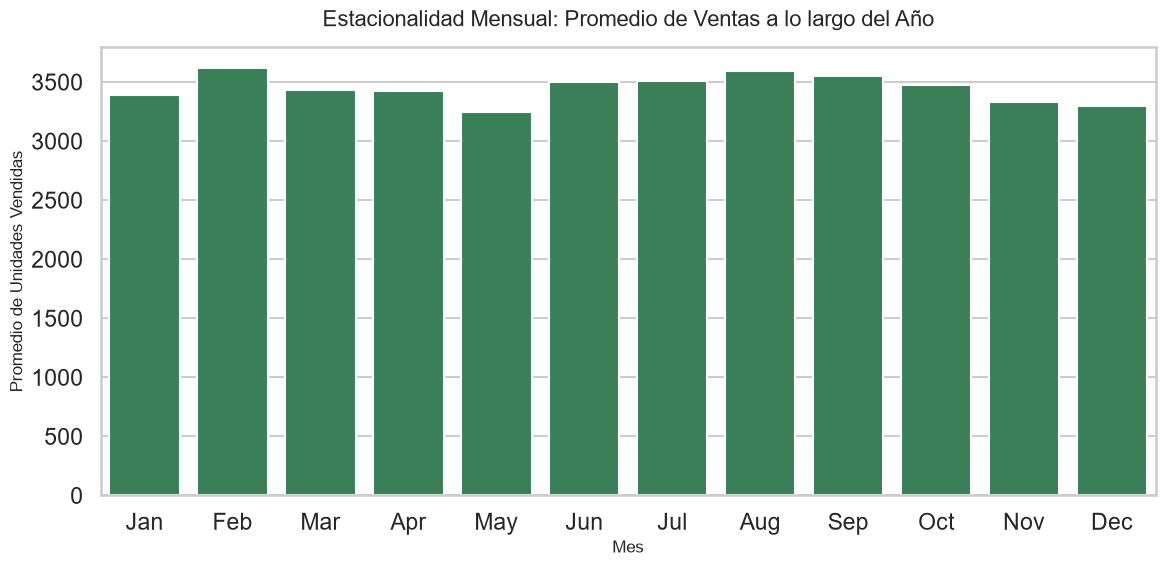

In [18]:
# --- GRÁFICO 2: ESTACIONALIDAD MENSUAL ---
# Mapeamos los números de mes a nombres para que sea más legible
meses_orden = [calendar.month_abbr[i] for i in range(1, 13)]
df_tiendas['month_name'] = df_tiendas['month'].apply(lambda x: calendar.month_abbr[x])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_tiendas, 
    x='month_name', 
    y='sales_qty', 
    order=meses_orden, 
    color='seagreen',
    errorbar=None
)

plt.title('Estacionalidad Mensual: Promedio de Ventas a lo largo del Año', fontsize=16, pad=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Promedio de Unidades Vendidas', fontsize=12)
plt.tight_layout()
plt.show()

Calculando el top de eventos con mayor impacto en ventas...


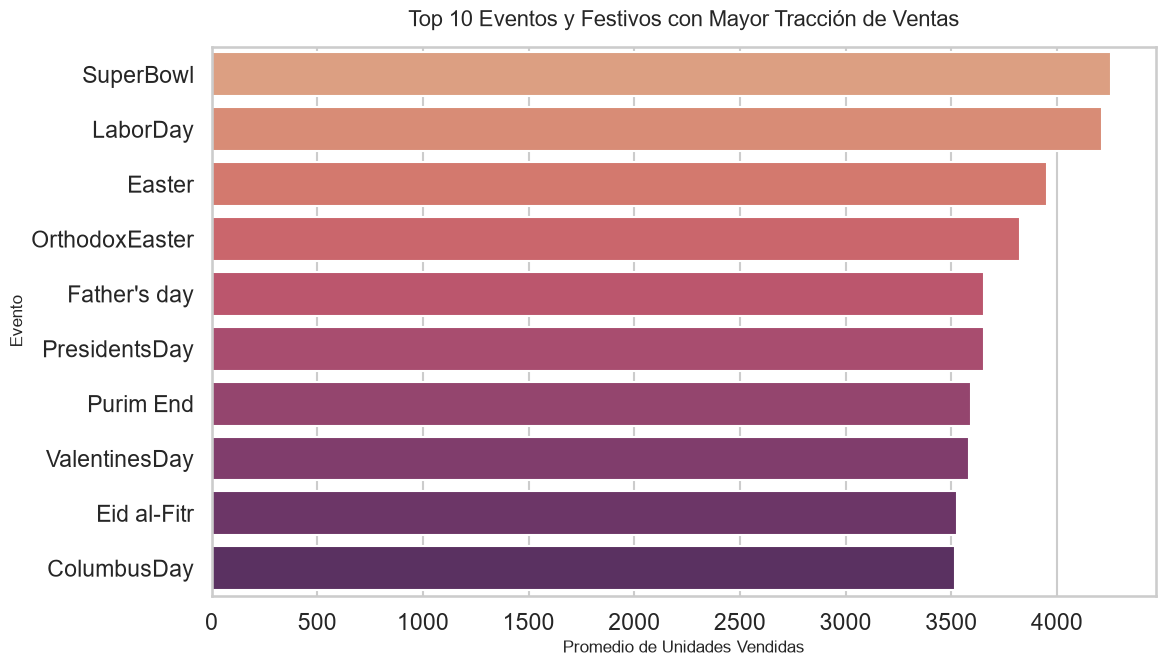

In [19]:
# --- GRÁFICO 3: IMPACTO DE EVENTOS ---
print("Calculando el top de eventos con mayor impacto en ventas...")

# 1. Filtramos los días normales
df_eventos = df_tiendas[df_tiendas['event_name_1'] != 'Sin Evento']

# 2. Calculamos la media de ventas por evento y cogemos los 10 mejores
top_eventos = df_eventos.groupby('event_name_1')['sales_qty'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
# Usamos un gráfico de barras horizontal (barplot) porque los nombres de los eventos son largos
sns.barplot(
    x=top_eventos.values, 
    y=top_eventos.index, 
    hue=top_eventos.index,
    palette='flare',
    legend=False
)

plt.title('Top 10 Eventos y Festivos con Mayor Tracción de Ventas', fontsize=16, pad=15)
plt.xlabel('Promedio de Unidades Vendidas', fontsize=12)
plt.ylabel('Evento', fontsize=12)
plt.tight_layout()
plt.show()

Generando gráficos ACF y PACF para la tienda CA_3 (Validación Matemática)...


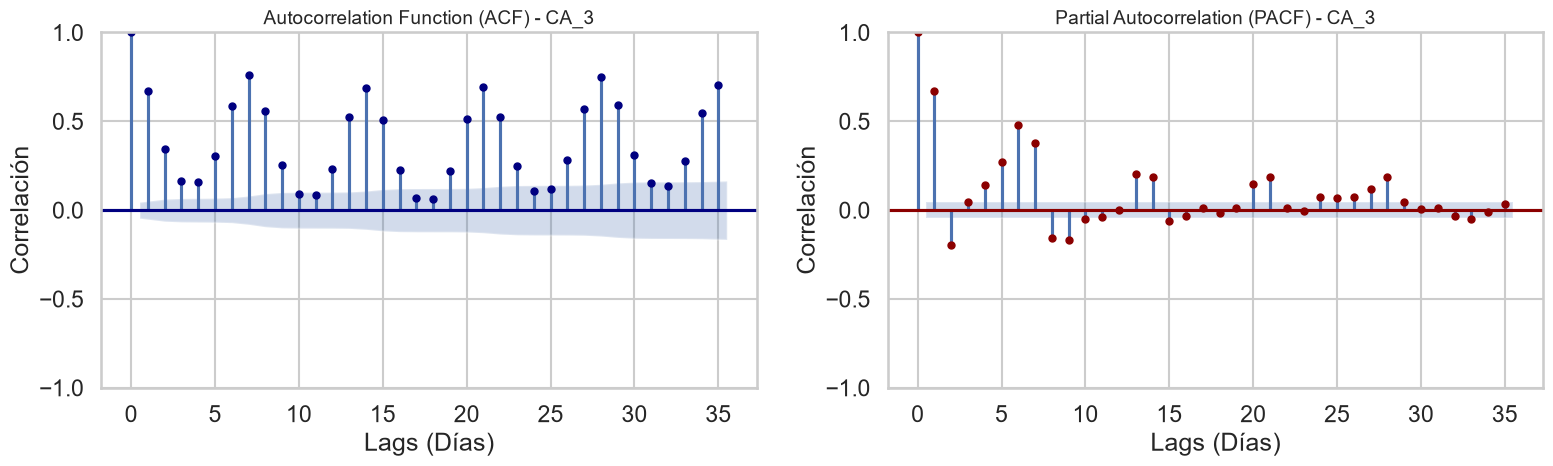

In [20]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("Generando gráficos ACF y PACF para la tienda CA_3 (Validación Matemática)...")

# 1. Aislamos los datos de la tienda CA_3 y los ordenamos cronológicamente
df_ca3 = df_tiendas[df_tiendas['store_id'] == 'CA_3'].copy()
df_ca3 = df_ca3.sort_values('date')

# 2. Preparamos el lienzo visual (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 3. Gráfico ACF (Autocorrelación Simple)
plot_acf(
    df_ca3['sales_qty'], 
    lags=35, 
    ax=axes[0], 
    color='navy',
    alpha=0.05 # Nivel de significancia del 95% (Bandas de confianza)
)
axes[0].set_title('Autocorrelation Function (ACF) - CA_3', fontsize=14)
axes[0].set_xlabel('Lags (Días)')
axes[0].set_ylabel('Correlación')

# 4. Gráfico PACF (Autocorrelación Parcial)
plot_pacf(
    df_ca3['sales_qty'], 
    lags=35, 
    ax=axes[1], 
    color='darkred', 
    method='ywm', # Método robusto de cálculo
    alpha=0.05
)
axes[1].set_title('Partial Autocorrelation (PACF) - CA_3', fontsize=14)
axes[1].set_xlabel('Lags (Días)')
axes[1].set_ylabel('Correlación')

plt.tight_layout()
plt.show()

### 📊 Exploratory Data Analysis (EDA): Análisis Univariante

El **Análisis Univariante** consiste en estudiar el comportamiento y la distribución de una sola variable de forma aislada. Este paso es un pilar fundamental en la exploración de datos:
* **Comprender la base:** Nos permite visualizar la "forma" y la naturaleza real de nuestro negocio antes de introducir mayor complejidad.
* **Diagnóstico inicial:** Ayuda a identificar patrones puros, distribuciones y posibles anomalías sin la interferencia de otros factores.
* **Secuencia lógica:** Es el paso metodológico previo y obligatorio antes de comenzar a cruzar variables (Análisis Bivariante o Multivariante).

💡 **Nota metodológica:** Conocer a fondo cómo se comporta cada variable por separado (por ejemplo, el volumen de ventas diarias o la distribución histórica de precios) es lo que nos dará el contexto necesario para interpretar correctamente los resultados de los modelos predictivos más adelante.

Iniciando Análisis Univariante (Distribuciones)...


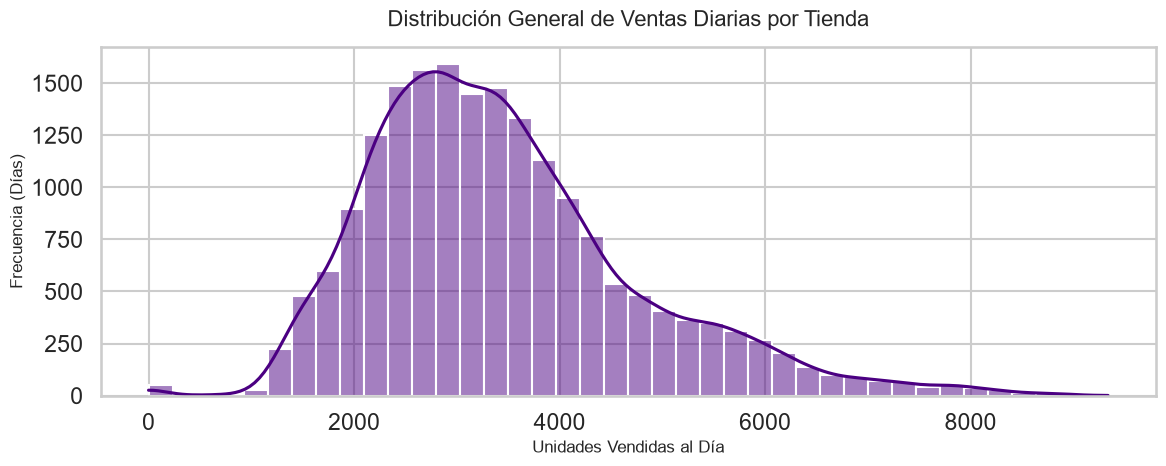

Cargando la columna de precios desde el archivo maestro...


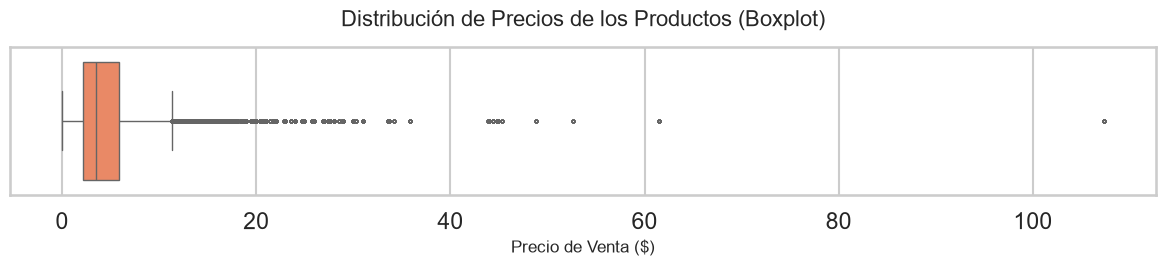

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Iniciando Análisis Univariante (Distribuciones)...")

# --- 1. DISTRIBUCIÓN DE VENTAS DIARIAS (Usando df_tiendas) ---
plt.figure(figsize=(12, 5))
sns.histplot(data=df_tiendas, x='sales_qty', bins=40, kde=True, color='indigo')

plt.title('Distribución General de Ventas Diarias por Tienda', fontsize=16, pad=15)
plt.xlabel('Unidades Vendidas al Día', fontsize=12)
plt.ylabel('Frecuencia (Días)', fontsize=12)
plt.tight_layout()
plt.show()

# --- 2. DISTRIBUCIÓN DE PRECIOS (Lectura quirúrgica del Parquet) ---
print("Cargando la columna de precios desde el archivo maestro...")
ruta_parquet = "./data/processed/abt_master_full.parquet" 
df_precios = pd.read_parquet(ruta_parquet, columns=["sell_price"])

# Al haber 58 millones de filas, un boxplot es mucho más rápido e informativo 
# que un histograma para detectar valores atípicos (outliers) en los precios.
plt.figure(figsize=(12, 3))
sns.boxplot(x=df_precios['sell_price'], color='coral', fliersize=2)

plt.title('Distribución de Precios de los Productos (Boxplot)', fontsize=16, pad=15)
plt.xlabel('Precio de Venta ($)', fontsize=12)
plt.tight_layout()
plt.show()

# Limpiamos memoria eliminando el dataframe de precios
del df_precios

In [26]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

print("1. Cargando datos estrictamente necesarios...")
columnas = ["store_id", "item_id", "sales_qty", "sell_price"]
df_raw_cluster = pd.read_parquet("./data/processed/abt_master_full.parquet", columns=columnas)

print("2. Agrupando a nivel Producto/Tienda...")
# Creamos la matriz matemática base
df_features = df_raw_cluster.groupby(["store_id", "item_id"]).agg(
    ventas_totales=("sales_qty", "sum"),
    varianza_ventas=("sales_qty", "var"),
    precio_medio=("sell_price", "mean")
).reset_index()

# Si un producto se ha vendido solo 1 vez (o en 1 solo día), su varianza será NaN. 
# Lo rellenamos con 0 matemáticamente correcto.
df_features["varianza_ventas"] = df_features["varianza_ventas"].fillna(0)

# Liberamos RAM destruyendo el dataframe crudo
del df_raw_cluster

print("3. Escalando las variables (Standardization)...")
scaler = StandardScaler()
columnas_a_escalar = ["ventas_totales", "varianza_ventas", "precio_medio"]

# Creamos las columnas con el sufijo _scaled
nombres_escalados = [col + "_scaled" for col in columnas_a_escalar]
df_features[nombres_escalados] = scaler.fit_transform(df_features[columnas_a_escalar])

print(f"✅ ¡Matriz lista! Filas para agrupar: {df_features.shape[0]:,}")
display(df_features.head())

1. Cargando datos estrictamente necesarios...
2. Agrupando a nivel Producto/Tienda...
3. Escalando las variables (Standardization)...
✅ ¡Matriz lista! Filas para agrupar: 30,490


,store_id,item_id,ventas_totales,varianza_ventas,precio_medio,ventas_totales_scaled,varianza_ventas_scaled,precio_medio_scaled
0,CA_1,FOODS_1_001,1464,1.576950,2.169591,-0.129305,-0.072262,-0.648144
1,CA_1,FOODS_1_002,905,0.651011,8.935596,-0.237744,-0.083090,1.273845
2,CA_1,FOODS_1_003,1567,1.358999,2.970053,-0.109324,-0.074811,-0.420761
3,CA_1,FOODS_1_004,15797,76.618569,1.847001,2.651133,0.805289,-0.739781
4,CA_1,FOODS_1_005,2143,3.924993,3.333676,0.002414,-0.044803,-0.317468


Entrenando modelos K-Means y calculando métricas...
⏳ Calculando Silhouette Score para 30,490 filas (esto puede tardar unos segundos)...
✅ Terminado K=2 -> Silhouette Score: 0.5373
✅ Terminado K=3 -> Silhouette Score: 0.5395
✅ Terminado K=4 -> Silhouette Score: 0.5754
✅ Terminado K=5 -> Silhouette Score: 0.5935
✅ Terminado K=6 -> Silhouette Score: 0.5001
✅ Terminado K=7 -> Silhouette Score: 0.5113


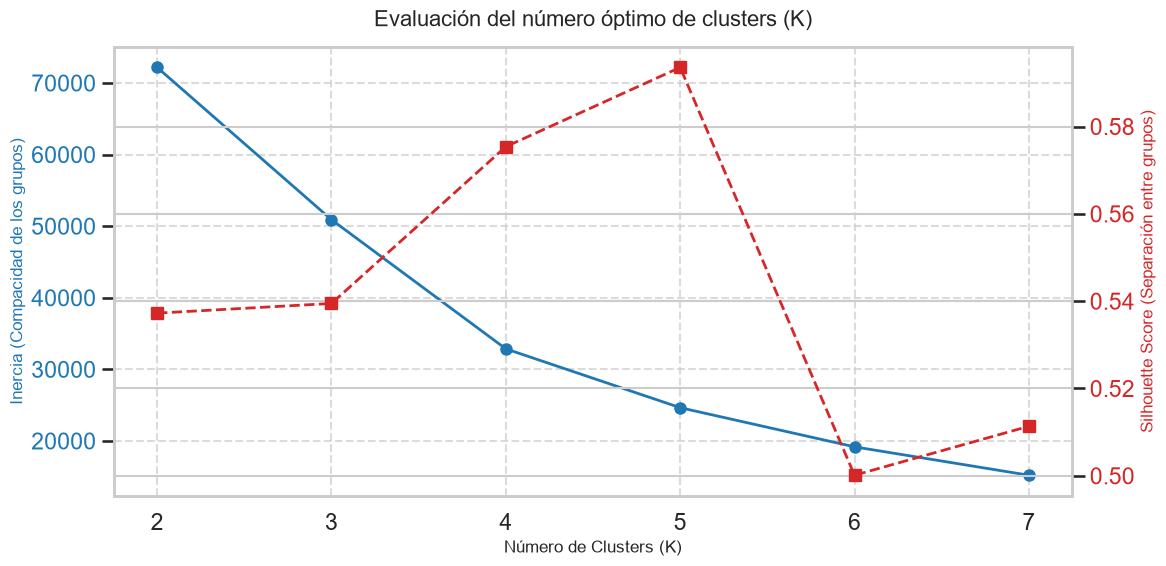

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

print("Entrenando modelos K-Means y calculando métricas...")
print("⏳ Calculando Silhouette Score para 30,490 filas (esto puede tardar unos segundos)...")

# 1. Aislamos solo las variables matemáticas (escaladas) para el algoritmo
X = df_features[["ventas_totales_scaled", "varianza_ventas_scaled", "precio_medio_scaled"]]

# Rango de clusters a evaluar
rango_k = range(2, 8)
inercia = []
puntuaciones_silueta = []

# 2. Iteramos probando diferentes valores de K
for k in rango_k:
    # Entrenamos el modelo. Usamos random_state=42 para que el resultado sea siempre el mismo
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    etiquetas = kmeans.fit_predict(X)
    
    # Guardamos la Inercia (para el Codo)
    inercia.append(kmeans.inertia_)
    
    # Guardamos el Silhouette Score
    score = silhouette_score(X, etiquetas)
    puntuaciones_silueta.append(score)
    print(f"✅ Terminado K={k} -> Silhouette Score: {score:.4f}")

# 3. Graficamos ambos resultados en un solo gráfico con dos ejes Y
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje Y principal (Izquierda) - Inercia
color_inercia = 'tab:blue'
ax1.set_xlabel('Número de Clusters (K)', fontsize=12)
ax1.set_ylabel('Inercia (Compacidad de los grupos)', color=color_inercia, fontsize=12)
ax1.plot(rango_k, inercia, marker='o', color=color_inercia, linewidth=2, markersize=8)
ax1.tick_params(axis='y', labelcolor=color_inercia)
ax1.grid(True, linestyle='--', alpha=0.7)

# Segundo Eje Y (Derecha) - Silhouette Score
ax2 = ax1.twinx()  
color_silueta = 'tab:red'
ax2.set_ylabel('Silhouette Score (Separación entre grupos)', color=color_silueta, fontsize=12)
ax2.plot(rango_k, puntuaciones_silueta, marker='s', color=color_silueta, linewidth=2, linestyle='dashed', markersize=8)
ax2.tick_params(axis='y', labelcolor=color_silueta)

plt.title('Evaluación del número óptimo de clusters (K)', fontsize=16, pad=15)
fig.tight_layout()  
plt.show()

In [28]:
from sklearn.cluster import KMeans

print("Ejecutando K-Means definitivo con K=5...")

# 1. Entrenamos el modelo final
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init="auto")

# 2. Predecimos y asignamos el cluster a nuestro DataFrame
# Nota: Seguimos usando 'X' que contiene las columnas _scaled
df_features['cluster'] = kmeans_final.fit_predict(X)

print("✅ Clustering completado. Analizando el perfil de cada grupo...")

# 3. Perfilamos los clusters usando las variables ORIGINALES (no escaladas) 
# para que el Director de Ventas lo entienda.
perfil_clusters = df_features.groupby('cluster')[['ventas_totales', 'varianza_ventas', 'precio_medio']].mean().round(2)

# Añadimos una columna para saber cuántos productos han caído en cada cluster
perfil_clusters['num_productos'] = df_features.groupby('cluster').size()

# Reordenamos las columnas para que se lea mejor
perfil_clusters = perfil_clusters[['num_productos', 'ventas_totales', 'varianza_ventas', 'precio_medio']]

print("\n--- Perfil Promedio de los 5 Segmentos de Productos ---")
display(perfil_clusters)

Ejecutando K-Means definitivo con K=5...
✅ Clustering completado. Analizando el perfil de cada grupo...

--- Perfil Promedio de los 5 Segmentos de Productos ---


,num_productos,ventas_totales,varianza_ventas,precio_medio
cluster,,,,
0,23623,1520.56,2.97,3.23
1,5541,793.67,1.05,10.31
2,1,249051.00,11791.13,1.34
3,1256,15714.53,77.80,1.75
4,69,67483.54,740.00,1.42


### 🎯 Resultados del Clustering: Perfilado y Estrategia de Negocio

Tras entrenar el modelo, hemos traducido las métricas matemáticas (volumen, precio y varianza) en cinco perfiles comerciales claramente diferenciados. Este es el mapa de nuestro catálogo:

* **Cluster 0 ➔ "El Catálogo Base"** (23,623 productos)
  * **Perfil:** Son el grueso del catálogo. Ventas medias-bajas (1,520 uds), precio medio estándar (3.23) y varianza muy baja (2.97).
  * 💡 **Insight:** Es nuestro "fondo de armario". Se venden por goteo constante, sin sorpresas. Garantizan flujo de caja regular sin necesidad de marketing agresivo.

* **Cluster 1 ➔ "Premium / Nicho"** (5,541 productos)
  * **Perfil:** Precio medio altísimo (10.31), ventas muy bajas (793) y varianza mínima (1.05).
  * 💡 **Insight:** Artículos caros de baja rotación y alto margen. Su stock debe estar milimetrado para evitar inmovilizar capital financiero.

* **Cluster 2 ➔ "El Unicornio del Volumen"** (1 producto)
  * **Perfil:** Un *outlier* puro. 249,051 ventas, varianza extrema (11,791) y precio de 1.34.
  * 💡 **Insight:** Una anomalía de negocio crítica con nombre y apellidos. Si este único producto falla, las métricas globales de volumen de la empresa se desploman.

* **Cluster 3 ➔ "Alta Rotación / Fast-Movers"** (1,256 productos)
  * **Perfil:** Precio bajo (1.75), ventas muy fuertes (15,714) y volatilidad moderada.
  * 💡 **Insight:** Son los "ganchos" del supermercado. Aquí nos jugamos la cuota de mercado; las roturas de stock en este segmento castigarían severamente la lealtad del cliente.

* **Cluster 4 ➔ "Blockbusters Volátiles"** (69 productos)
  * **Perfil:** Ventas estratosféricas (67,483) con una varianza altísima (740) y precio bajo (1.42).
  * 💡 **Insight:** Artículos de comportamiento errático, fuertemente estacionales o sujetos a promociones agresivas. Exigen vigilancia diaria por parte del equipo de *Supply Chain*.